<a href="https://colab.research.google.com/github/ayamgoyenx/522362-GraceAnreMarcheline-ResponsiJuniorProject/blob/master/ColabNAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Before starting:
* This notebook is meant to run on Google Colaboratory;
* It requires you to download a third party software, otherwise it will not run. (I know it's tedious but I don't own the program and so I can't share it with you);
* I suggest to use an environment with a GPU.


##Preliminaries

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Install 'tensorflow-model-optimization' for Quantization Aware Training (QAT)

###Get 'stm32tflm' software

* Download 'X-CUBE-AI-Linux' package from https://www.st.com/en/embedded-software/x-cube-ai.html;
* Extract the 'stm32tflm' executable from the downloaded package;
* Put it in the folder you're working (usually '/content/' for Google Colaboratory).

Enable the execution of the 'stm32tflm' program

In [58]:
#giving permit for files to be executed
!chmod +x /content/drive/MyDrive/nastrial/stm32tflm

In [59]:
pip install tensorflow-model-optimization

##ColabNAS code

In [60]:
from tensorflow_model_optimization.python.core.keras.compat import keras
from pathlib import Path
import tensorflow as tf
import numpy as np
import subprocess
import datetime
import shutil
import glob
import re
import os

class ColabNAS :
    architecture_name = 'resulting_architecture'
    def __init__(self, max_RAM, max_Flash, max_MACC, path_to_training_set, val_split, cache=False, input_shape=(50,50,3), save_path='.', path_to_stm32tflm='/content/drive/MyDrive/nastrial/stm32tflm') :
        self.learning_rate = 1e-3
        self.batch_size = 128
        self.epochs = 100 #minimum 2

        self.max_MACC = max_MACC
        self.max_Flash = max_Flash
        self.max_RAM = max_RAM
        self.path_to_training_set = path_to_training_set          # pakai parameter, bukan hardcode
        self.num_classes = len(next(os.walk(self.path_to_training_set))[1])
        self.val_split = val_split                                 # pakai parameter, bukan hardcode
        self.cache = cache
        self.input_shape = input_shape                             # pakai parameter, bukan hasil perkalian
        self.save_path = Path(save_path)

        self.path_to_trained_models = self.save_path / "trained_models"
        self.path_to_trained_models.mkdir(parents=True, exist_ok=True)

        self.path_to_stm32tflm = Path(path_to_stm32tflm)

        self.load_training_set()

    # k number of kernels of the first convolutional layer
    # c number of cells added upon the first convolutional layer
    # pre-processing pipeline not included in MACC computation
    def Model(self, k, c) :
        kernel_size = (3,3)
        pool_size = (2,2)
        pool_strides = (2,2)

        number_of_cells_limited = False
        number_of_mac = 0

        inputs = keras.Input(shape=self.input_shape)

        #convolutional base
        n = int(k)
        multiplier = 2

        #first convolutional layer
        c_in = self.input_shape[2]
        x = keras.layers.Conv2D(n, kernel_size, padding='same')(inputs)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.ReLU()(x)

        number_of_mac = number_of_mac + (c_in * kernel_size[0] * kernel_size[1] * x.shape[1] * x.shape[2] * x.shape[3])

        #adding cells
        for i in range(1, c + 1) :
            if x.shape[1] <= 1 or x.shape[2] <= 1 :
                number_of_cells_limited = True
                break;
            n = int(np.ceil(n * multiplier))
            multiplier = multiplier - 2**-i
            x = keras.layers.MaxPooling2D(pool_size=pool_size, strides=pool_strides, padding='valid')(x)
            c_in = x.shape[3]
            x = keras.layers.Conv2D(n, kernel_size, padding='same')(x)
            x = keras.layers.BatchNormalization()(x)
            x = keras.layers.ReLU()(x)
            number_of_mac = number_of_mac + (c_in * kernel_size[0] * kernel_size[1] * x.shape[1] * x.shape[2] * x.shape[3])

        #classifier
        x = keras.layers.GlobalAveragePooling2D()(x)
        input_shape = x.shape[1]
        x = keras.layers.Dense(n)(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.ReLU()(x)
        number_of_mac = number_of_mac + (input_shape * x.shape[1])
        x = keras.layers.Dense(self.num_classes)(x)
        x = keras.layers.BatchNormalization()(x)
        outputs = keras.layers.Softmax()(x)
        number_of_mac = number_of_mac + (x.shape[1] * outputs.shape[1])

        model = keras.Model(inputs=inputs, outputs=outputs)

        opt = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=opt,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

        model.summary()

        return model, number_of_mac, number_of_cells_limited

    def load_training_set(self):
        if 3 == self.input_shape[2] :
            color_mode = 'rgb'
        elif 1 == self.input_shape[2] :
            color_mode = 'grayscale'

        train_ds = tf.keras.utils.image_dataset_from_directory(
            directory= self.path_to_training_set,
            labels='inferred',
            label_mode='categorical',
            color_mode=color_mode,
            batch_size=self.batch_size,
            image_size=self.input_shape[0:2],
            shuffle=True,
            seed=11,
            validation_split=self.val_split,
            subset='training'
        )

        validation_ds = tf.keras.utils.image_dataset_from_directory(
            directory= self.path_to_training_set,
            labels='inferred',
            label_mode='categorical',
            color_mode=color_mode,
            batch_size=self.batch_size,
            image_size=self.input_shape[0:2],
            shuffle=True,
            seed=11,
            validation_split=self.val_split,
            subset='validation'
        )

        data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.2, fill_mode='constant', interpolation='bilinear'),
            #tf.keras.layers.Rescaling(1./255)
            ])

        if self.cache :
            self.train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
            self.validation_ds = validation_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
        else :
            self.train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(buffer_size=tf.data.AUTOTUNE)
            self.validation_ds = validation_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    def quantize_model_uint8(self) :
        def representative_dataset():
            for data in self.train_ds.rebatch(1).take(150) :
                yield [tf.dtypes.cast(data[0], tf.float32)]

        model = tf.keras.models.load_model(self.path_to_trained_models / f"{self.model_name}.h5")
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.uint8
        converter.inference_output_type = tf.uint8
        tflite_quant_model = converter.convert()

        with open(self.path_to_trained_models / f"{self.model_name}.tflite", 'wb') as f:
            f.write(tflite_quant_model)

        (self.path_to_trained_models / f"{self.model_name}.h5").unlink()

    def evaluate_flash_and_peak_RAM_occupancy(self) :
        #quantize model to evaluate its peak RAM occupancy and its Flash occupancy
        self.quantize_model_uint8()

        #evaluate its peak RAM occupancy and its Flash occupancy using STMicroelectronics' X-CUBE-AI
        proc = subprocess.Popen([self.path_to_stm32tflm, self.path_to_trained_models / f"{self.model_name}.tflite"], stdout=subprocess.PIPE)
        try:
            outs, errs = proc.communicate(timeout=15)
            Flash, RAM = re.findall(r'\d+', str(outs))
        except subprocess.TimeoutExpired:
            proc.kill()
            outs, errs = proc.communicate()
            print("stm32tflm error")
            exit()

        return int(Flash), int(RAM)

    def evaluate_model_process(self, k, c) :
        if k > 0 :
            self.model_name = f"k_{k}_c_{c}"
            print(f"\n{self.model_name}\n")
            checkpoint = tf.keras.callbacks.ModelCheckpoint(
                str(self.path_to_trained_models / f"{self.model_name}.h5"), monitor='val_accuracy',
                verbose=1, save_best_only=True, save_weights_only=False, mode='auto')
            model, MACC, number_of_cells_limited = self.Model(k, c)
            #One epoch of training must be done before quantization, which is needed to evaluate RAM and Flash occupancy
            model.fit(self.train_ds, epochs=1, validation_data=self.validation_ds, validation_freq=1)
            model.save(self.path_to_trained_models / f"{self.model_name}.h5")
            Flash, RAM = self.evaluate_flash_and_peak_RAM_occupancy()
            print(f"\nRAM: {RAM},\t Flash: {Flash},\t MACC: {MACC}\n")
            if MACC <= self.max_MACC and Flash <= self.max_Flash and RAM <= self.max_RAM and not number_of_cells_limited :
                hist = model.fit(self.train_ds, epochs=self.epochs - 1, validation_data=self.validation_ds, validation_freq=1, callbacks=[checkpoint])
                self.quantize_model_uint8()
            return {'k': k,
                    'c': c if not number_of_cells_limited else "Not feasible",
                    'RAM': RAM if RAM <= self.max_RAM else "Outside the upper bound",
                    'Flash': Flash if Flash <= self.max_Flash else "Outside the upper bound",
                    'MACC': MACC if MACC <= self.max_MACC else "Outside the upper bound",
                    'max_val_acc':
                    np.around(np.amax(hist.history['val_accuracy']), decimals=3)
                    if 'hist' in locals() else -3}
        else :
            return{'k': 'unfeasible', 'c': c, 'max_val_acc': -3}

    def explore_num_cells(self, k) :
        previous_architecture = {'k': -1, 'c': -1, 'max_val_acc': -2}
        current_architecture = {'k': -1, 'c': -1, 'max_val_acc': -1}
        c = -1
        k = int(k)

        while(current_architecture['max_val_acc'] > previous_architecture['max_val_acc']) :
            previous_architecture = current_architecture
            c = c + 1
            self.model_counter = self.model_counter + 1
            current_architecture = self.evaluate_model_process(k, c)
            print(f"\n\n\n{current_architecture}\n\n\n")
        return previous_architecture

    def search(self) :
        self.model_counter = 0
        epsilon = 0.005
        k0 = 4

        start = datetime.datetime.now()

        k = k0
        previous_architecture = self.explore_num_cells(k)
        k = 2 * k
        current_architecture = self.explore_num_cells(k)

        if (current_architecture['max_val_acc'] > previous_architecture['max_val_acc']) :
            previous_architecture = current_architecture
            k = 2 * k
            current_architecture = self.explore_num_cells(k)
            while(current_architecture['max_val_acc'] > previous_architecture['max_val_acc'] + epsilon) :
                previous_architecture = current_architecture
                k = 2 * k
                current_architecture = self.explore_num_cells(k)
        else :
            k = k0 / 2
            current_architecture = self.explore_num_cells(k)
            while(current_architecture['max_val_acc'] >= previous_architecture['max_val_acc']) :
                previous_architecture = current_architecture
                k = k / 2
                current_architecture = self.explore_num_cells(k)

        resulting_architecture = previous_architecture

        end = datetime.datetime.now()

        if (resulting_architecture['max_val_acc'] > 0) :
            resulting_architecture_name = f"k_{resulting_architecture['k']}_c_{resulting_architecture['c']}.tflite"
            self.path_to_resulting_architecture = self.save_path / f"resulting_architecture_{resulting_architecture_name}"
            (self.path_to_trained_models / f"{resulting_architecture_name}").rename(self.path_to_resulting_architecture)
            shutil.rmtree(self.path_to_trained_models)
            print(f"\nResulting architecture: {resulting_architecture}\n")
        else :
            print(f"\nNo feasible architecture found\n")
        print(f"Elapsed time (search): {end-start}\n")

        return self.path_to_resulting_architecture

##Try ColabNAS!

###Run HW-NAS
target: STM32L412KBU3 (273 CoreMark, 40 kiB RAM, 128 kiB Flash)

In [ ]:
import numpy as np
# import tensorflow as tf

peak_RAM_upper_bound = 250        # KiB
Flash_upper_bound = 250           # KiB
MACC_upper_bound = 6_650_000      # dari estimasi CoreMark ESP32-S3
path_to_training_set = '/content/drive/MyDrive/nastrial/colabnas_dataset'
val_split = 0.2
cache = True
input_shape = (96, 96, 1)
save_path = '/content/drive/MyDrive/nastrial'

colabNAS = ColabNAS(
    peak_RAM_upper_bound,
    Flash_upper_bound,
    MACC_upper_bound,
    path_to_training_set,
    val_split,
    cache,
    input_shape,
    save_path,
)


#to show the GPU used
!nvidia-smi

colabNAS = ColabNAS(peak_RAM_upper_bound, Flash_upper_bound, MACC_upper_bound, path_to_training_set, val_split, cache, input_shape, save_path)

#search
path_to_tflite_model = colabNAS.search()

Found 325 files belonging to 2 classes.
Using 260 files for training.
Found 325 files belonging to 2 classes.
Using 65 files for validation.
Tue Sep 22 18:52:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             31W /   70W |     421MiB /  15360MiB |      0%      Default |

/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



RAM: 48640,	 Flash: 3664,	 MACC: 331796




{'k': 4, 'c': 0, 'RAM': 'Outside the upper bound', 'Flash': 'Outside the upper bound', 'MACC': 331796, 'max_val_acc': -3}




k_8_c_0

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 96, 96, 1)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 96, 96, 8)         80        
                                                                 
 batch_normalization_6 (Bat  (None, 96, 96, 8)         32        
 chNormalization)                                                
                                                                 
 re_lu_4 (ReLU)              (None, 96, 96, 8)         0         
                                                                 
 global_average_pooling2d_2  (None, 8)                 0         
  (GlobalAv

/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



RAM: 85504,	 Flash: 3984,	 MACC: 663620




{'k': 8, 'c': 0, 'RAM': 'Outside the upper bound', 'Flash': 'Outside the upper bound', 'MACC': 663620, 'max_val_acc': -3}




k_2_c_0

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 96, 96, 1)]       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 96, 96, 2)         20        
                                                                 
 batch_normalization_9 (Bat  (None, 96, 96, 2)         8         
 chNormalization)                                                
                                                                 
 re_lu_6 (ReLU)              (None, 96, 96, 2)         0         
                                                                 
 global_average_pooling2d_3  (None, 2)                 0         
  (GlobalAv

...


RAM: 30208,	 Flash: 3528,	 MACC: 165896




{'k': 2, 'c': 0, 'RAM': 'Outside the upper bound', 'Flash': 'Outside the upper bound', 'MACC': 165896, 'max_val_acc': -3}




k_1_c_0

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 96, 96, 1)]       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 96, 96, 1)         10        
                                                                 
 batch_normalization_12 (Ba  (None, 96, 96, 1)         4         
 tchNormalization)                                               
                                                                 
 re_lu_8 (ReLU)              (None, 96, 96, 1)         0         
                                                                 
 global_average_pooling2d_4  (None, 1)                 0         
  (GlobalAv

3/3 [==============================] - ETA: 0s - loss: 0.8774 - accuracy: 0.5462

3/3 [==============================] - 6s 1s/step - loss: 0.8774 - accuracy: 0.5462 - val_loss: 0.6919 - val_accuracy: 0.5231


/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Streaming output truncated to the last 5000 lines.






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc': -3}






{'k': 'unfeasible', 'c': 0, 'max_val_acc':

###Test the obtained model

a useful function for testing 'tflite' models

In [ ]:
def test_tflite_model(path_to_resulting_model, test_ds) :
    interpreter = tf.lite.Interpreter(str(path_to_resulting_model))
    interpreter.allocate_tensors()

    output = interpreter.get_output_details()[0]  # Model has single output.
    input = interpreter.get_input_details()[0]  # Model has single input.

    correct = 0
    wrong = 0

    for i in test_ds :
        image, label = i[0], i[1]
        # Check if the input type is quantized, then rescale input data to uint8
        if input['dtype'] == tf.uint8:
            input_scale, input_zero_point = input["quantization"]
            image = image / input_scale + input_zero_point
        input_data = tf.dtypes.cast(image, tf.uint8)
        interpreter.set_tensor(input['index'], input_data)
        interpreter.invoke()
        if label.numpy().argmax() == interpreter.get_tensor(output['index']).argmax() :
            correct = correct + 1
        else :
            wrong = wrong + 1
    print(f"\nTflite model test accuracy: {correct/(correct+wrong)}")

download a new image, not used in training

In [ ]:
import tensorflow as tf

# 1. Tentukan input_shape terlebih dahulu
input_shape = (96, 96, 1)

# 2. Masukkan path lokal gambar secara langsung
sunflower_path = "/content/drive/MyDrive/nastrial/IMG_2949.jpg"

# 3. Muat gambar langsung dari path lokal
img = tf.keras.utils.load_img(
    sunflower_path,
    target_size=input_shape[0:2],
    color_mode='grayscale'
)

# 4. Konversi ke array dan ubah ke 1D
img_array = tf.keras.utils.img_to_array(img)
flat_img = tf.reshape(img_array, [-1])

print("Shape 1D:", flat_img.shape)

In [ ]:
img

build a dataset containing the new image

In [ ]:
img_array = tf.expand_dims(img_array, 0) # Create a batch

img_label = tf.constant([[0., 0., 0., 1., 0.]]) #sunflower

test_ds = tf.data.Dataset.from_tensor_slices((img_array, img_label))
test_ds = test_ds.batch(1)

test the obtained model

In [ ]:
test_tflite_model('/content/drive/MyDrive/nastrial/trained_models/k_8_c_0.tflite', test_ds)

testing trained models in esp32-s3

In [ ]:
#installing mcufit
!pip install mcufit

In [ ]:
!mcufit check '/content/drive/MyDrive/nastrial/trained_models/k_8_c_0.tflite' -b esp32-s3

In [ ]:
!mcufit --help

Round 1: MAX_RAM 100KiB, MAX_FLASH 100 KiB, MACC_UPPER_BOUND 6_650_000

accuracy: 0.0 semuanya
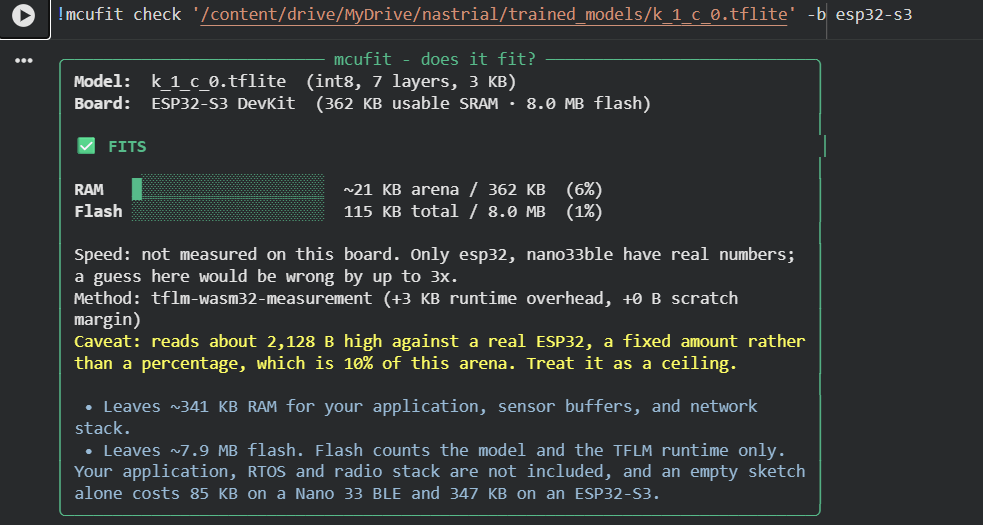

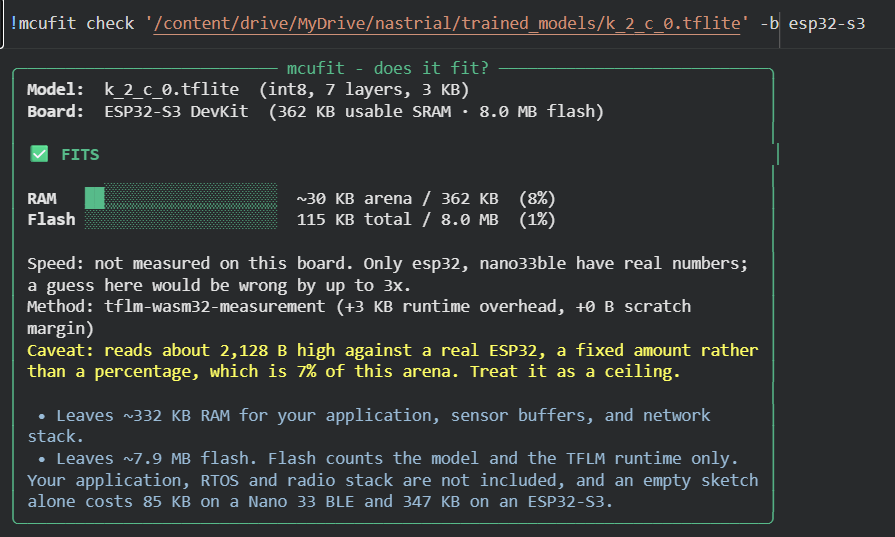

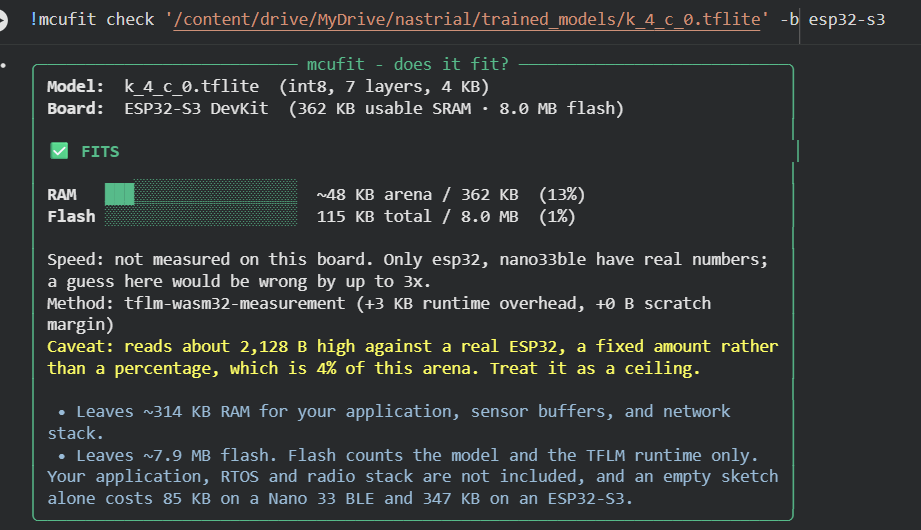

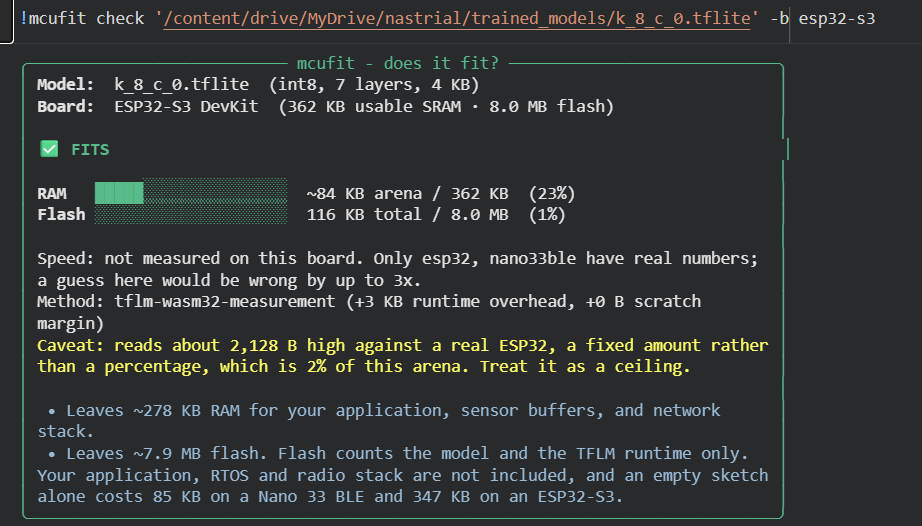
